In [8]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#109747'
NONTARGET_COLOR = 'black'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [9]:
import re

import numpy as np

_VALID_SEPARATORS = frozenset(' ,\n\t\r')


def _clean_numpy_repr(s: str) -> str:
    s = s.replace('array(', '')
    s = re.sub(r',?\s*dtype=\w+\s*', '', s)
    s = s.replace(')', '')
    return s


def str_to_np(s: str) -> np.ndarray:
    if not isinstance(s, str) or not s.strip():
        raise ValueError("Input must be a non-empty string")
    s = s.strip()
    s = _clean_numpy_repr(s)
    result, pos = _parse(s, 0)
    pos = _skip_separators(s, pos)
    if pos < len(s):
        raise ValueError(
            f"Unexpected trailing content at position {pos}: "
            f"'{s[pos:pos + 20]}{'...' if len(s) - pos > 20 else ''}'"
        )
    return _to_numpy(result)


def _skip_separators(s: str, i: int) -> int:
    while i < len(s) and s[i] in _VALID_SEPARATORS:
        i += 1
    return i


def _parse(s: str, i: int):
    i = _skip_separators(s, i)
    if i >= len(s):
        raise ValueError("Unexpected end of string")
    if s[i] == '[':
        return _parse_list(s, i)
    return _parse_atom(s, i)


def _parse_list(s: str, i: int):
    i += 1
    items = []
    while True:
        i = _skip_separators(s, i)
        if i >= len(s):
            raise ValueError("Unclosed list, missing closing ']'")
        if s[i] == ']':
            return items, i + 1
        if s[i] == '[':
            item, i = _parse_list(s, i)
        else:
            item, i = _parse_atom(s, i)
        items.append(item)


def _parse_atom(s: str, i: int):
    j = i
    while j < len(s) and s[j] not in _VALID_SEPARATORS and s[j] not in '[]':
        j += 1
    if j == i:
        raise ValueError(f"Empty token at position {i}")
    token = s[i:j]
    if token.lower() == 'nan':
        return np.nan, j
    if token == 'True':
        return True, j
    if token == 'False':
        return False, j
    try:
        return float(token), j
    except ValueError:
        raise ValueError(
            f"Invalid token at position {i}: '{token}' is not a valid number, 'nan', 'True', or 'False'"
        )


def _to_numpy(x):
    if not isinstance(x, list):
        return np.array(x)
    if len(x) == 0:
        return np.array([])

    child_is_list = [isinstance(item, list) for item in x]

    if all(child_is_list):
        children = [_to_numpy(item) for item in x]
        shapes = [a.shape for a in children]
        dtypes = [a.dtype for a in children]

        if len(set(dtypes)) > 1:
            raise ValueError(
                "Mixed types across sub-arrays: all sub-arrays must have the same dtype"
            )

        if len(set(shapes)) == 1:
            try:
                return np.array(children)
            except Exception:
                arr = np.empty(len(children), dtype=object)
                for i, c in enumerate(children):
                    arr[i] = c
                return arr
        else:
            arr = np.empty(len(children), dtype=object)
            for i, c in enumerate(children):
                arr[i] = c
            return arr

    if not any(child_is_list):
        types = {type(v) for v in x}
        if types == {bool}:
            return np.array(x, dtype=bool)
        if types <= {float}:
            return np.array(x, dtype=float)
        raise ValueError(
            "Mixed types in array: cannot mix booleans with numbers"
        )

    raise ValueError(
        "Mixed content in list: some items are arrays and some are scalars"
    )


In [10]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 1e.csv'))

In [11]:
df

,Unnamed: 0,animal,session,phase,column,cluster,FR modulation,trials,response times,spike times,laser status
0,0,DS_19,DS_19_14_AC.pickle,post expert,4,19,19.142157,[254 255 256 257 258 259 260 261 262 263 264 2...,[ nan 1.62833333e+02 1.41366667e+02 ...,"[array([-747.33333333, -412.46666667, -283.833...",[False False False False False False False Fal...
1,1,BS_49,BS_49_1_AC.pickle,pre early,3,143,11.074977,[ 0 1 2 3 4 5 6 7 8 9 10 ...,[1.85163333e+03 2.30156667e+03 3.89666667e+01 ...,"[array([-702.5 , -498.23333333, -73.166...",[False False False False False False False Fal...
2,2,BS_49,BS_49_1_AC.pickle,pre early,1,150,1.788618,[ 0 1 2 3 4 5 6 7 8 9 10 ...,[1.85163333e+03 2.30156667e+03 3.89666667e+01 ...,"[array([ 11.6 , 86.03333333, 704.3 ...",[False False False False False False False Fal...
3,3,DS_19,DS_19_16_AC.pickle,post expert,3,68,22.723577,[ 47 48 49 50 51 52 53 54 55 56 57 ...,[ 910.33333333 nan 176.16666667 2...,"[array([-177.46666667, 934.46666667])\n array...",[False False False False False False False Fal...
4,4,BS_41,BS_41_9_AC.pickle,post late,4,37,20.890493,[ 46 47 48 49 50 51 52 53 54 55 56 ...,[1.73786667e+03 6.88333333e+01 3.74333333e+01 ...,"[array([ 165.3 , 565.26666667, 1227.666...",[False False False False False False False Fal...
5,5,BS_108,BS_108_1_AC.pickle,pre expert,3,9,15.806452,[330 331 332 333 334 335 336 337 338 339 340 3...,[ 99.8 84.53333333 120.7 8...,"[array([-425.06666667, -356.13333333, -328.4 ...",[False False False False False False False Fal...
6,6,BS_49,BS_49_9_AC.pickle,pre late,3,45,4.076923,[ 12 13 14 15 16 17 18 19 20 21 22 ...,[4.32100000e+02 7.76333333e+01 1.79300000e+02 ...,"[array([-557.26666667, -439.9 , -213.4 ...",[False False False False False False False Fal...
7,7,DS_15,DS_15_13_AC.pickle,post expert,2,41,3.678930,[ 0 1 2 3 4 5 6 7 8 9 10 ...,[9.84666667e+01 9.94666667e+01 9.63666667e+01 ...,"[array([-742.83333333, -507.16666667, -82.266...",[False False False False False False False Fal...
8,8,DS_15,DS_15_1_AC.pickle,pre expert,4,16,40.598802,[300 301 302 303 304 305 306 307 308 309 310 3...,[ 183.73333333 124.5 106.9 4...,"[array([ -91.66666667, -78.73333333, -35.133...",[False False False False False False False Fal...
9,9,DS_15,DS_15_1_AC.pickle,pre expert,2,59,6.107784,[300 301 302 303 304 305 306 307 308 309 310 3...,[ 183.73333333 124.5 106.9 4...,"[array([-686.33333333, -612.93333333, -512.3 ...",[False False False False False False False Fal...


# Add Folders

In [11]:
os.mkdir(os.path.join('..','..','Figure 1e','pngs'))
os.mkdir(os.path.join('..','..','Figure 1e','pdfs'))

# Plotting Code

In [12]:
def visualizeClusterChoiceInternal(row,ax1,ax2,Figure_start_time_ms=-250,Figure_end_time_ms=1000,xtickstouse=[0,500,1000],xticklabelstouse=None,align_to_choice=False,switch_cond='NA',limitToUse=None,bw=5):
    buffer = 250
    sort_by_response_latency = False # Not implemented
    bw_scott_factor = bw
    
    mn = 3.5
    spread = 2
    
    ax2.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax2.tick_params(direction='out')

    Y = row['FR modulation']
    if np.isnan(Y):
        color_to_use = 'k'
    else:
        color_to_use = NCR_CR_cmap( (Y-(mn-spread/2))/ (spread) )

    trialsToPlot = str_to_np(row['trials'])
    trialSpikes = str_to_np(row['spike times'])

    #Plot Raster
    count = 0
    for idx,trial in enumerate(trialsToPlot):
        if count < 30:
            X = trialSpikes[idx]
            try:
                Y = np.ones_like(trialSpikes[idx])*count
            except Exception as e:
                print(trialSpikes[idx])
                raise e
            mask = np.logical_and( np.greater(X,Figure_start_time_ms) , np.less(X,Figure_end_time_ms) )
            if np.sum(mask) > 0:
                X = X[mask]
                Y = Y[mask]
                ax1.scatter(X,Y,color=color_to_use,s=9.,marker=2,lw=1.5,zorder=0,clip_on=False)
                count += 1
    
    
    #Set trial limits
    max_trial_value = len(trialsToPlot)
    sequence_of_possible_axis_limits = np.array([1,2,4,6,8,10,12,16,20,30])#,40,50,60,80,100,120,140,150,160,180,200])#,220,240,260,280,300,320,340,360,380,400])
    idx_of_okay_limits = np.less_equal(sequence_of_possible_axis_limits,max_trial_value)
    valid_limits = sequence_of_possible_axis_limits[idx_of_okay_limits]
    if not len(valid_limits) > 0:
        return False,[]
    limit = np.max(valid_limits)
    ax1.set_xlim([Figure_start_time_ms,Figure_end_time_ms])
    ax1.set_ylim([0,limit])
    ax1.set_yticks([])

    #Plot PSTH
    starttime = Figure_start_time_ms
    endtime = Figure_end_time_ms
    xrange = np.linspace(starttime,endtime,num=1000)
    numSplits = min(10,len(trialSpikes))
    if numSplits < 2:
        return False,[] ### Return a failure
    FR = np.full((numSplits,len(xrange)),np.nan)
    kf = KFold(n_splits=numSplits)
    for idx,(_,train_index) in enumerate(kf.split(trialSpikes)):
        PSTHspikes = np.concatenate(trialSpikes[train_index])
        if len(PSTHspikes) == 0:
            FR[idx,:] = np.zeros(len(xrange))
            continue
        bw = len(PSTHspikes)**(-1./5) / bw_scott_factor
        KDE = gaussian_kde(PSTHspikes,bw_method=bw)
        FR[idx,:] = KDE.evaluate(xrange)
        FR[idx,:] = FR[idx,:] * len(PSTHspikes) / len(train_index) * 1000 #1000 is conversion to s/s because units are all in ms for this plot
    avg_FR = np.mean(FR,axis=0)
    sem_FR = sem(FR,axis=0)
    ax2.plot(xrange,avg_FR,lw=2,color=color_to_use)
    ax2.fill_between(xrange,avg_FR-sem_FR,avg_FR+sem_FR,color=color_to_use,alpha=0.1,zorder=-10,lw=0)

    #PSTH Limits
    if limitToUse is None:
        max_FR_value = np.max(avg_FR+sem_FR) * 1.1
        sequence_of_possible_axis_limits = np.array([1,2,4,6,8,10,12,16,20,30,40,50,60,80,100,120,140,150,160,180,200])
        idx_of_okay_limits = np.greater_equal(sequence_of_possible_axis_limits,max_FR_value)
        valid_limits = sequence_of_possible_axis_limits[idx_of_okay_limits]
        limit = np.min(valid_limits)
    else:
        limit  = limitToUse
    ###
#     limit = 30
    ###
    ax2.set_ylim([0,limit])
    ax2.set_yticks([0,limit])
    ax2.set_yticklabels(['0',str(limit)])
    ylab = ax2.set_ylabel('')#Firing rate\n(spikes/s)')
    
    ### X limits
    ax1.set_xlim([starttime,endtime])
    ax2.set_xlim([starttime,endtime])
    ax1.set_xticks(np.array(xtickstouse))
    if xticklabelstouse is None:
        ax1.set_xticklabels(np.array(xtickstouse))
    else:
        ax1.set_xticklabels(xticklabelstouse)
    if align_to_choice:
        xlab = ax1.set_xlabel('Time (s)')
    else:
        xlab = ax1.set_xlabel('Time (s)')
    ax2.set_xticks([])
    
    ### Tone bar
    if not align_to_choice:
        ax2.plot([0,100],[limit]*2,c='k',lw=2,clip_on=False,zorder=10)
        
#     ### Stim bar
    if not align_to_choice:
        ax1.plot([0,0],ax1.get_ylim(),linestyle='--',lw=1,color='gray',zorder=-10,clip_on=False)
        ax2.plot([0,0],ax2.get_ylim(),linestyle='--',lw=1,color='gray',zorder=-10,clip_on=False)
    else:
        ax1.plot([0,0],[0,93],linestyle='--',lw=1,color='green',zorder=-10,clip_on=False)
    
    ################################################################
    
    #font size 15 old style. Font size 35 new style
    
    for axis in ['bottom','left']:
        ax1.spines[axis].set_linewidth(1.75)
        ax2.spines[axis].set_linewidth(1.75)
    ax1.tick_params(width=0)
    ax2.tick_params(width=1.75)
    for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
        ax1.get_xticklabels() + ax1.get_yticklabels()):
        item.set_fontsize(20)
    for item in ([ax2.title, ax2.xaxis.label, ax2.yaxis.label] +
        ax2.get_xticklabels() + ax2.get_yticklabels()):
        item.set_fontsize(20)
    
    artists = [ylab,xlab]
    plt.show()
    return True,artists

0it [00:00, ?it/s]

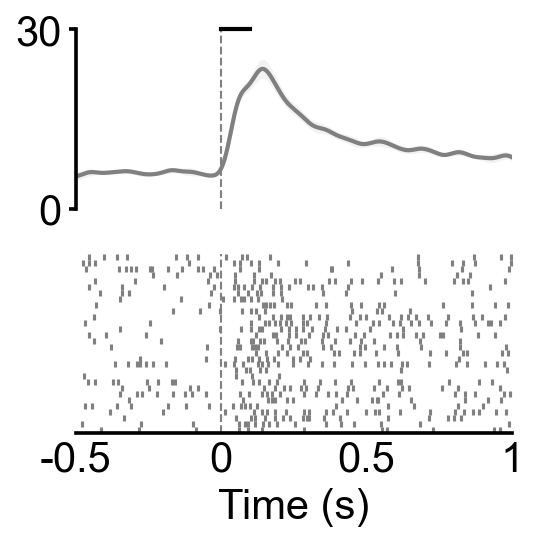

1it [00:00,  1.49it/s]

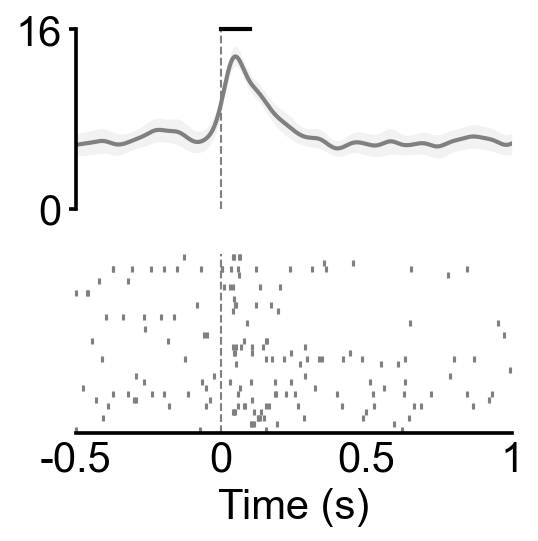

2it [00:01,  1.52it/s]

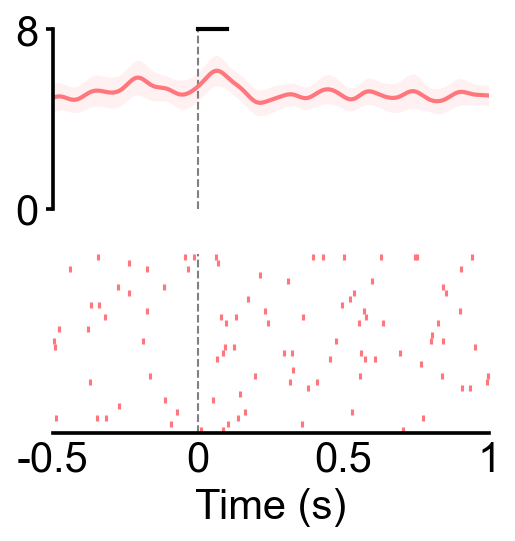

3it [00:01,  1.61it/s]

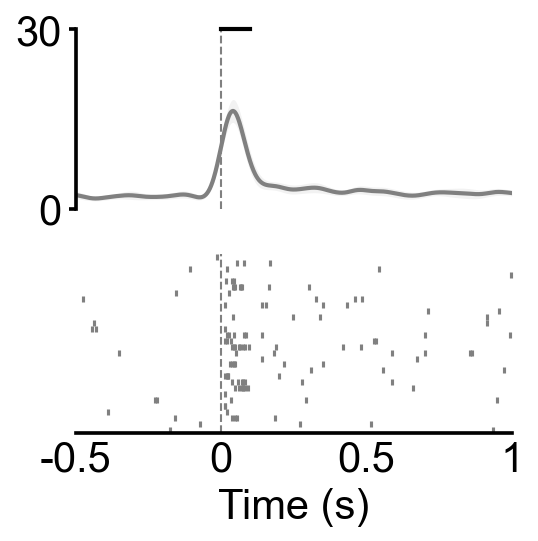

4it [00:02,  1.75it/s]

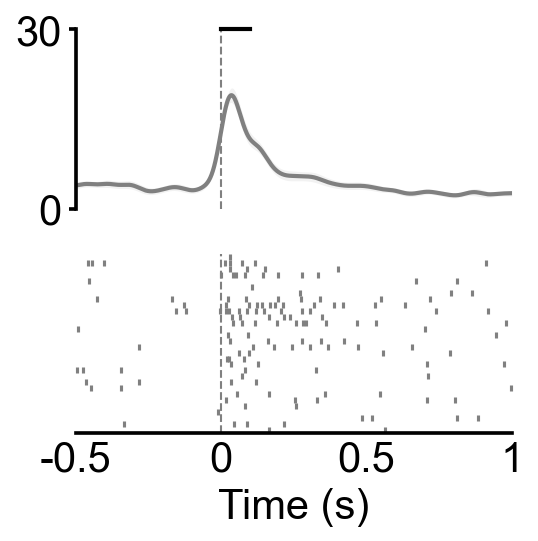

5it [00:03,  1.64it/s]

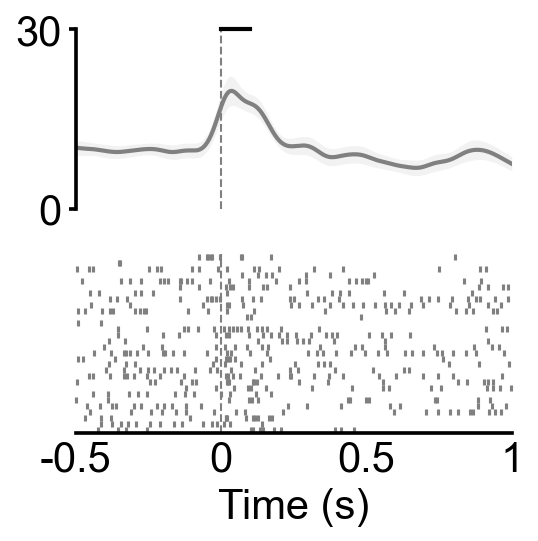

6it [00:03,  1.70it/s]

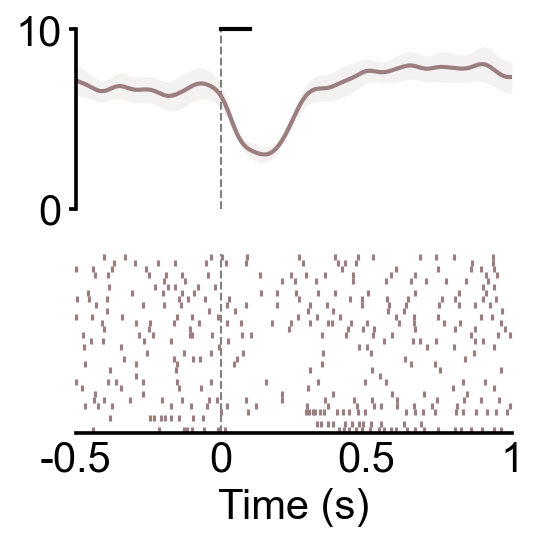

7it [00:04,  1.74it/s]

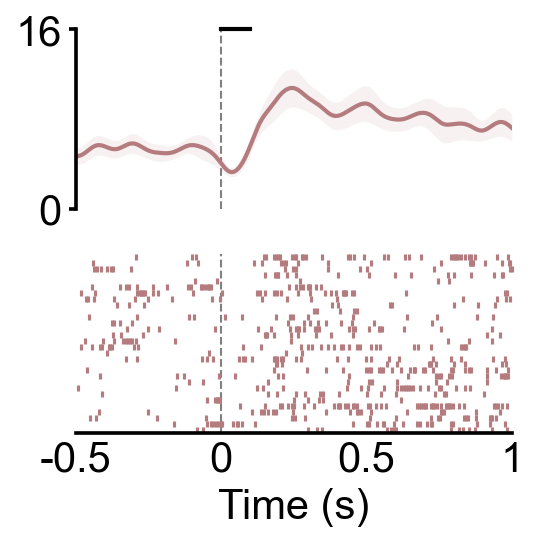

8it [00:04,  1.70it/s]

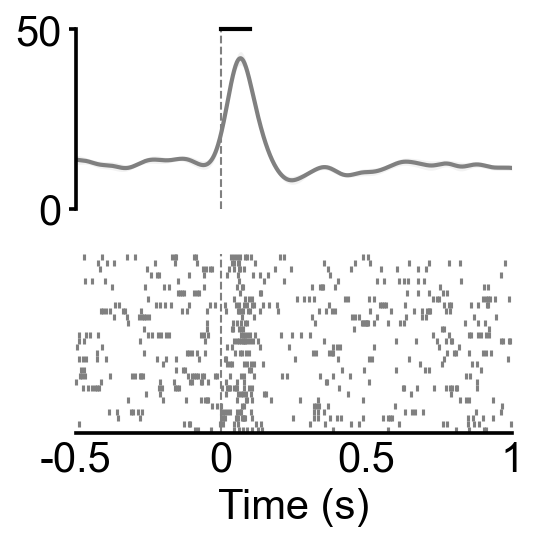

9it [00:05,  1.70it/s]

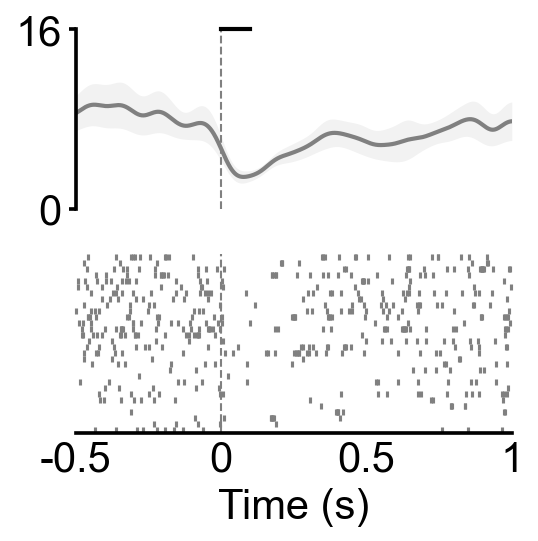

10it [00:05,  1.80it/s]

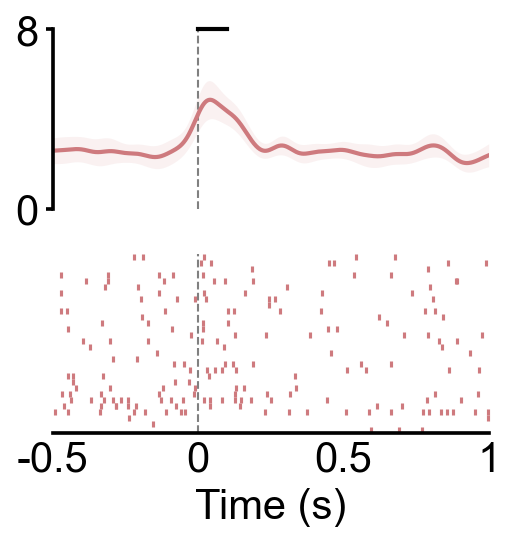

11it [00:06,  1.86it/s]

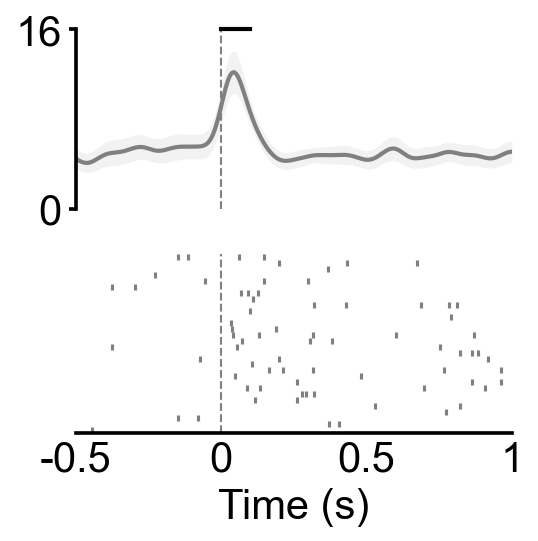

12it [00:06,  1.85it/s]

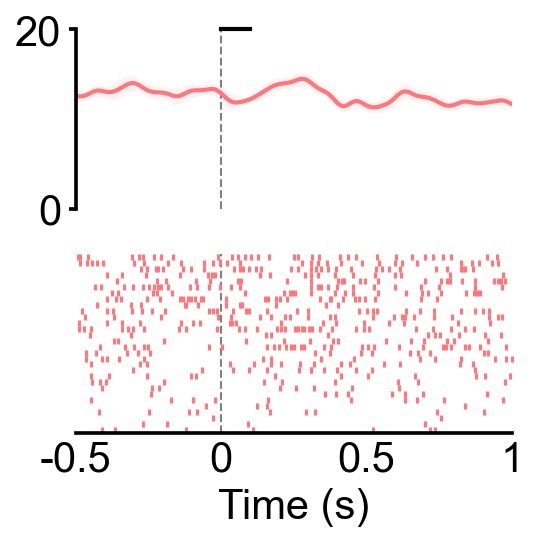

13it [00:07,  1.51it/s]

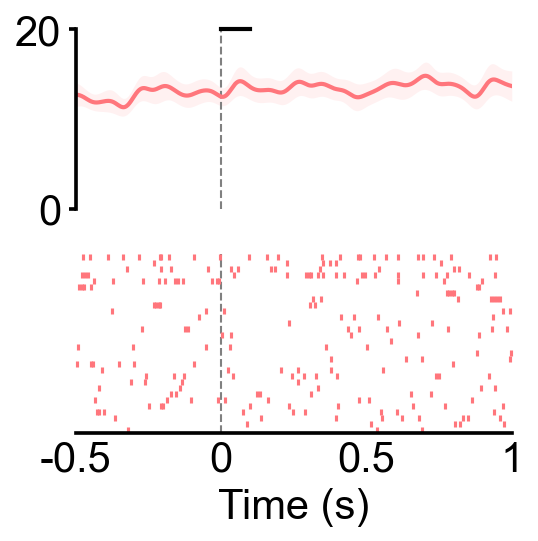

14it [00:09,  1.20it/s]

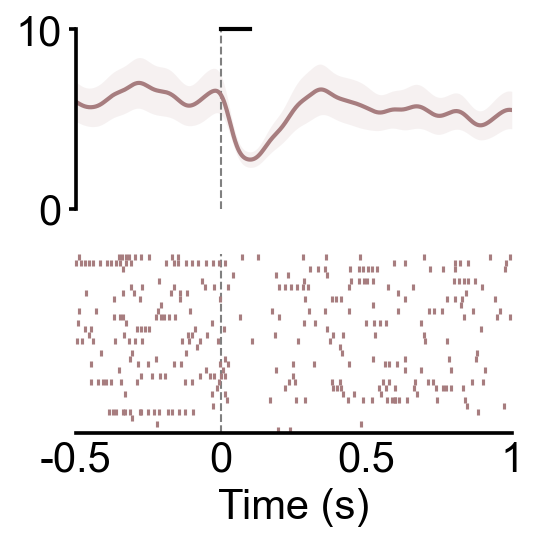

15it [00:09,  1.26it/s]

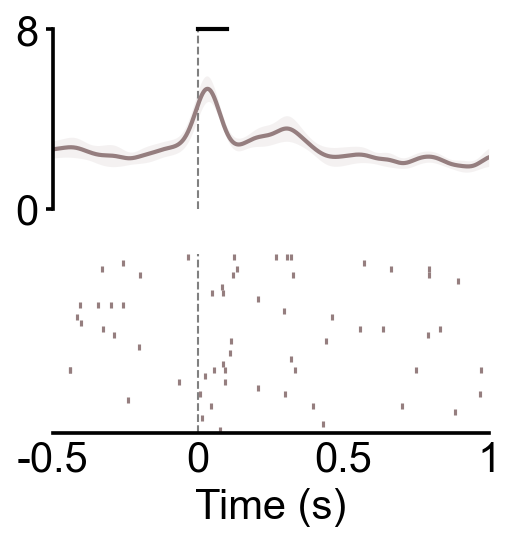

16it [00:10,  1.44it/s]

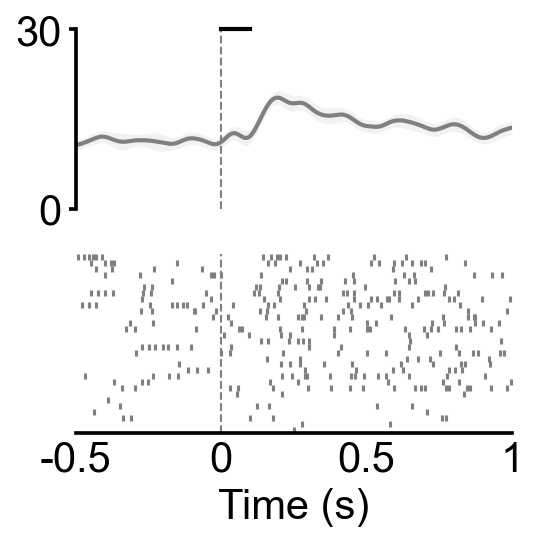

17it [00:11,  1.31it/s]

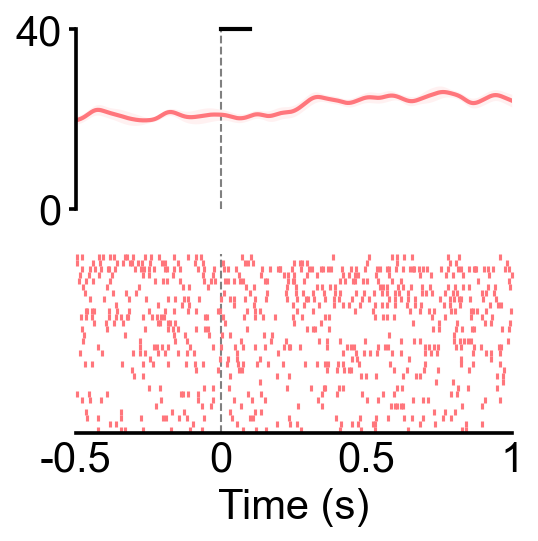

18it [00:12,  1.11it/s]

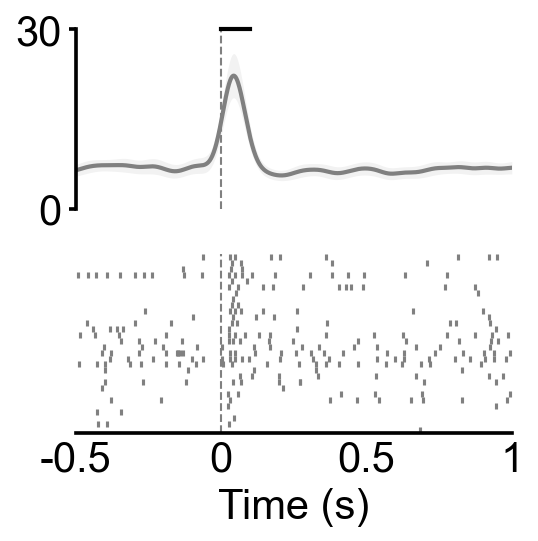

19it [00:12,  1.27it/s]

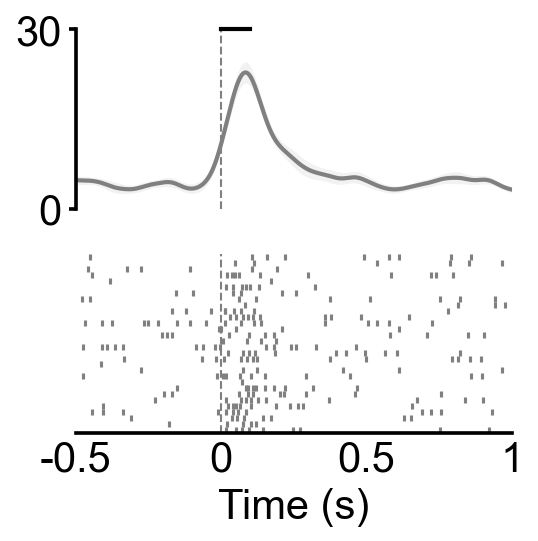

20it [00:13,  1.47it/s]

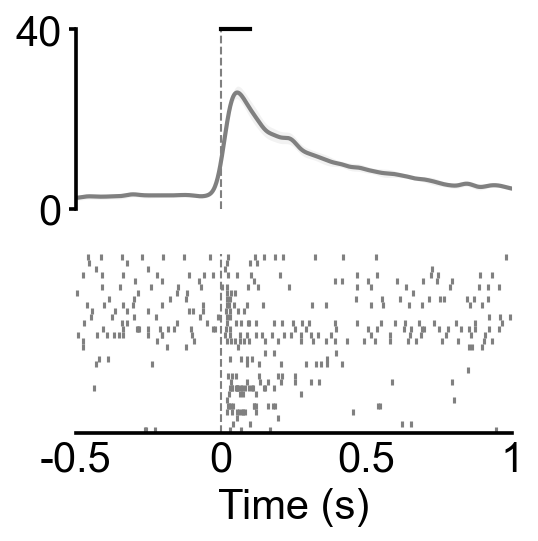

21it [00:14,  1.15it/s]

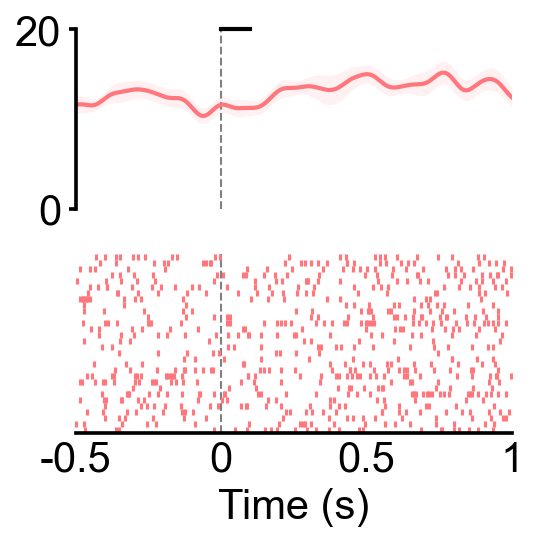

22it [00:15,  1.29it/s]

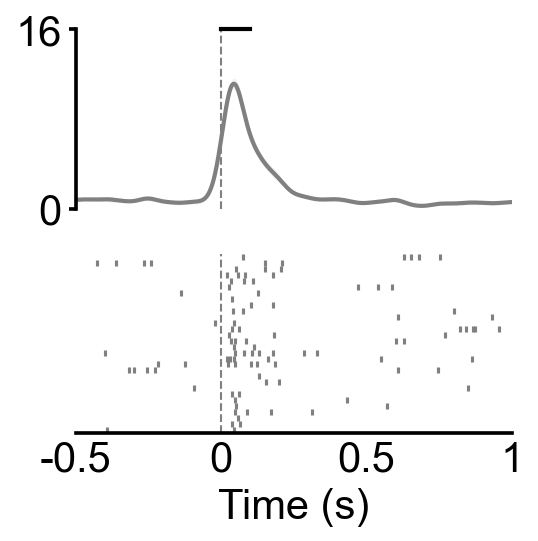

23it [00:15,  1.47it/s]

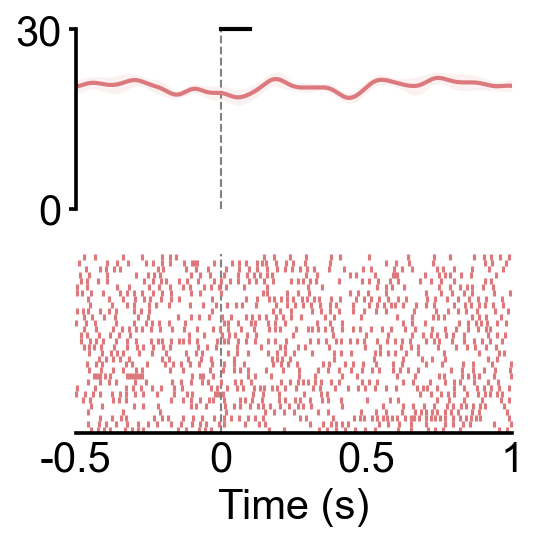

24it [00:16,  1.48it/s]


In [14]:
for row in tqdm(df.iloc):

    session = row['session']
    clust = row['cluster']
    phase = row['phase']
    
    limitToUse = None
    bw_to_use = 5
    skip = True
    
    plt.close('all')
    fig = plt.figure(figsize=(3.75,3.5))
    gs = fig.add_gridspec(2,1,height_ratios=[1,1],hspace=0.25)
    
    ax3 = plt.subplot(gs[1,0])
    ax4 = plt.subplot(gs[0,0])

    fst=-500
    fet=1000
    xt=[-500,0,500,1000]
    xtl=['-0.5','0','0.5','1']
    try:
        success,artists = visualizeClusterChoiceInternal(row,ax3,ax4,limitToUse=limitToUse,Figure_start_time_ms=fst,Figure_end_time_ms=fet,xtickstouse=xt,xticklabelstouse=xtl,bw=bw_to_use)
    except Exception as e:
        raise e
    if not success:
        print('Fail')
        continue
        
    # fig.savefig(os.path.join('..','..','Figures','Figure 1e','pdfs',f'{row['phase']} {row['column']}.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')
    # fig.savefig(os.path.join('..','..','Figures','Figure 1e','pngs',f'{row['phase']} {row['column']}.png'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')